# MAP and MLE point estimation

HSSM is a Bayesian package, but you do not always want a full posterior. Two
point estimates are available:

- **`model.find_MAP()`** — the *maximum a posteriori* estimate: the mode of the
  joint density, likelihood and priors together.
- **`model.find_MLE()`** — the *maximum likelihood* estimate: the mode of the
  observed likelihood alone, with the priors dropped.

Both are far cheaper than sampling — seconds on the simple models below,
though a large hierarchy (or `se=True` on one) takes longer — which makes them
useful for:

- **debugging a model specification** before committing to a sampling run,
- **cheap estimation** when you do not need the full posterior,
- **comparing** a frequentist point estimate against the Bayesian one,
- **initializing the sampler** via `model.sample(initvals="map")`.

A point estimate is not a posterior. It carries no uncertainty of its own —
`se=True` below adds asymptotic standard errors, but those are a normal
approximation around the mode, not the real posterior shape. For inference,
sample.

In [1]:
import arviz as az

import hssm

hssm.set_floatX("float64")

Setting PyTensor floatX type to float64.
Setting "jax_enable_x64" to True. If this is not intended, please set `jax` to False.


Point estimation is gradient-based, so it is sensitive to precision. Under
`hssm.set_floatX("float32")` the gradient noise exceeds the optimizer's default
tolerances and the optimizer can stop far from the optimum *while reporting
success*. HSSM warns and switches to a gradient-free method in that case, but
`float64` (the default) is what you want here.

In [2]:
dataset = hssm.simulate_data(
    model="ddm", theta=[0.5, 1.5, 0.5, 0.5], size=500, random_state=42
)
model = hssm.HSSM(data=dataset, model="ddm", loglik_kind="analytical")
dataset.head()

Model initialized successfully.


,rt,response
0,1.259133,1.0
1,4.182888,1.0
2,3.335714,1.0
3,3.490131,1.0
4,5.707030,-1.0


## Maximum a posteriori

In [3]:
estimate = model.find_MAP(progressbar=False)
estimate

MAP estimate (L-BFGS-B, converged, logp=-1027)
           estimate
parameter          
a          1.459973
t          0.512108
z          0.497889
v          0.481167

The returned object is a `PointEstimate`. It is a `dict` subclass — so it can
go anywhere a point dictionary was accepted before — carrying the raw optimizer
point (constrained values, transformed value-variable names such as `t_log__`,
and any deterministics) plus the optimizer metadata:

In [4]:
print("converged:", estimate.success)
print("method:   ", estimate.method)
print("logp:     ", estimate.logp)
print("message:  ", estimate.message)

estimate.params

converged: True
method:    L-BFGS-B
logp:      -1027.110353543079
message:   CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


{'a': array(1.45997307),
 't': array(0.51210766),
 'z': array(0.49788874),
 'v': array(0.48116658)}

`.params` holds only the constrained free parameters — the estimates you would
report. `.to_dataframe()` tidies them, one row per scalar entry.

### Standard errors

`se=True` adds the inverse Hessian at the optimum, computed on the untransformed
(constrained) scale. What that quantity *is* depends on which estimate you asked
for: for an MLE these are standard errors in the usual sense (the observed
information), while for a MAP they are posterior standard deviations under a
Laplace — normal — approximation around the mode. Same arithmetic, different
object.

Expect `NaN` when the optimum sits on a parameter bound or a parameter is weakly
identified; HSSM warns rather than raising in that case. The cost scales with
the number of parameters — `2n` gradient evaluations plus an `n × n` inverse —
so on a large hierarchy this step can outlast the optimization itself.

In [5]:
model.find_MAP(se=True, progressbar=False).to_dataframe()

,estimate,se
parameter,,
a,1.459973,0.036789
t,0.512108,0.027102
z,0.497889,0.018053
v,0.481167,0.046027


### Starting points matter

By default `find_MAP` starts from `model.initvals`, HSSM's own processed initial
values. This is not cosmetic: PyMC's default start (`t=2.0`) puts many models
where the *gradient* of the log-density is non-finite while the logp is still
finite, so the start check passes and the optimizer aborts without moving. HSSM
detects that and refuses to hand back the start point as if it were an
estimate.

In [6]:
model.initvals

{'a': array(1.5), 't': array(0.025), 'z': array(0.5), 'v': array(0.)}

If the optimizer does fail, `find_MAP` warns and returns `None`, and **nothing
is cached** — so a later `model.map` or `sample(initvals="map")` cannot silently
pick up a bogus point. Pass `strict=True` to turn the warning into an error.

`n_starts` runs the optimization from several jittered starting points and keeps
the best one, which helps on multimodal or badly conditioned problems:

In [7]:
multi = model.find_MAP(n_starts=3, seed=0, progressbar=False)
print(f"{multi.n_converged} of {multi.n_starts} starts converged")
print("best logp:", multi.logp)

find_MAP: 3 of 3 starts converged.
3 of 3 starts converged
best logp: -1027.1103533898117


## Maximum likelihood

In [8]:
mle = model.find_MLE(progressbar=False)
mle.to_dataframe()

,estimate
parameter,
a,1.460432
t,0.511961
z,0.497842
v,0.481510


To compare MAP and MLE, both points must be scored on the **same** objective.
The MAP maximizes the joint density and the MLE the observed likelihood, so
their `.logp` values are not comparable to each other. Scoring both on the
observed log-likelihood is the meaningful comparison — and the MLE should win by
construction:

In [9]:
from hssm.optimize import score_point

map_score = score_point(model.pymc_model, estimate, observed_only=True)
mle_score = score_point(model.pymc_model, mle, observed_only=True)

print(f"observed logp at MAP: {map_score:.4f}")
print(f"observed logp at MLE: {mle_score:.4f}")
print(f"difference:           {mle_score - map_score:.2e}")

observed logp at MAP: -1023.3322
observed logp at MLE: -1023.3321
difference:           9.71e-05


The gap is small here because the priors are weak relative to 500 trials. With
a small dataset or informative priors, the MAP is pulled further toward the
prior and the gap widens.

### MLE is refused on hierarchical models

Dropping the priors leaves the group-level scale unidentified, in either
parameterization:

- **Non-centered** (HSSM's default), where a group-level effect is
  `offset * sigma`: the likelihood is invariant under rescaling `offset` against
  `sigma`, so the optimum is a flat ridge.
- **Centered** (`noncentered=False`): `sigma` does not enter the likelihood at
  all, so its gradient is exactly zero and the optimizer simply leaves it where
  it started.

Either way there is no maximum to find, so `find_MLE` raises rather than
returning a number off the ridge.

MAP has no such problem — the priors pin the scale down — so use `find_MAP` for
hierarchical models. (`allow_unidentified=True` overrides the check if you know
what you are doing, e.g. for penalized-likelihood work; the estimate you get
back reports the group-level scale, but you should not read it as identified.)

In [10]:
hierarchical = hssm.HSSM(
    data=hssm.load_data("cavanagh_theta"),
    model="ddm",
    loglik_kind="analytical",
    include=[{"name": "v", "formula": "v ~ 1 + (1|participant_id)"}],
)

try:
    hierarchical.find_MLE()
except ValueError as error:
    print(error)

Model initialized successfully.
find_MLE is not well posed for hierarchical models. This model has group-specific terms ['1|participant_id']. Dropping the priors leaves the group-level scale unidentified: under the non-centered parameterization (HSSM's default) the likelihood is invariant under rescaling the offsets against sigma, and under the centered parameterization sigma does not enter the likelihood at all. Either way the optimum is a flat ridge rather than a point. Use `find_MAP()` instead, which is well behaved for these models, or pass `allow_unidentified=True` to proceed anyway.


In [11]:
hierarchical_map = hierarchical.find_MAP(progressbar=False)
hierarchical_map.to_dataframe().head(6)

,estimate
parameter,
a,1.081437
t,0.345613
z,0.477671
v_Intercept,0.503523
v_1|participant_id_sigma,0.661233
v_1|participant_id_offset[0],-0.561643


Note that a MAP over a hierarchy is the mode of the *joint* posterior over
population parameters and group-level offsets, not of the marginal posterior of
the population parameters.

## Using a point estimate downstream

### As a sampler starting point

In [12]:
model.sample(initvals="map", draws=100, tune=100, chains=1, cores=1, progressbar=False)
az.summary(model.traces)

Initializing NUTS using adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [a, t, z, v]
Sampling 1 chain for 100 tune and 100 draw iterations (100 + 100 draws total) took 1 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,1.455,0.035,1.4,1.5,84,76,nan,0.0039,0.0024
v,0.48,0.052,0.4,0.56,34,68,nan,0.0089,0.0043
t,0.518,0.028,0.47,0.56,47,54,nan,0.0041,0.0023
z,0.505,0.019,0.47,0.53,38,39,nan,0.0031,0.0022


### As a one-draw posterior

`to_datatree()` returns the estimate as a 1-chain, 1-draw posterior, which the
rest of the ArviZ and HSSM toolchain accepts — including posterior predictive
sampling and the plotting functions.

Read the summary with care: with a single draw there is no sampling
distribution, so `sd` is `0` and `ess_bulk`, `ess_tail` and `r_hat` come back
`NaN`. That is expected, not a diagnostic failure.

In [13]:
point_fit = estimate.to_datatree()
az.summary(point_fit)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,1.5,0,1.5,1.5,nan,nan,nan,nan,nan
t,0.51,0,0.51,0.51,nan,nan,nan,nan,nan
z,0.5,0,0.5,0.5,nan,nan,nan,nan,nan
v,0.48,0,0.48,0.48,nan,nan,nan,nan,nan


dt=None, we use the traces assigned to the HSSM object as datatree.


/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/Inccbrown/hssm-repo/implement_mle_map/.venv/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


n_samples > n_draws. Using the entire dataset.


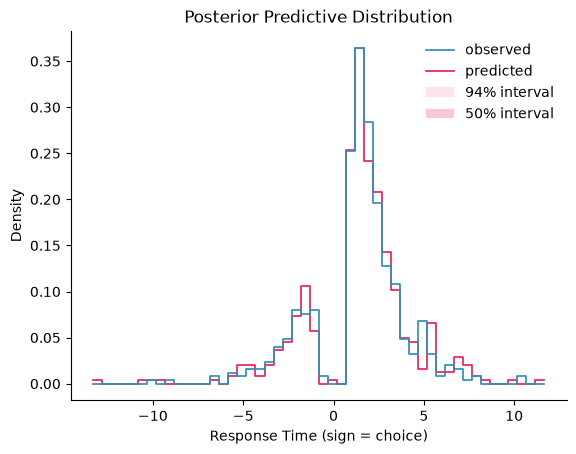

In [14]:
model.restore_traces(point_fit)
model.sample_posterior_predictive()
model.plot_predictive();

## A note on `sampler="laplace"`

`model.sample(sampler="laplace")` is provided by bambi, which gives HSSM no way
to pass initial values into its internal MAP step — so it always starts from
PyMC's default point, the one described above. When the gradient is non-finite
there, the "approximation" is a Gaussian centred on the *start point*, reported
without an error. HSSM warns when you request it.

Prefer `find_MAP()` followed by `sample()`, which is what this tutorial does.